🎬 MÓDULO DE VISUALIZACIONES DINÁMICAS - TFM MLB
🚀 INICIANDO CREACIÓN DE ANIMACIONES DINÁMICAS
✅ Datos cargados: 78,441 registros
📊 Período: 1940-2023
🎯 Registros era moderna: 78,441
📈 Creando 3 animaciones de 15 segundos cada una...
🎯 Período: 1940-2023 (84 años)

🎬 Creando animación: Evolución de Strikeouts...
💾 Guardando strikeout_evolution.mp4...
⚠️ ffmpeg no disponible, guardando como GIF...
✅ strikeout_evolution.gif guardado exitosamente


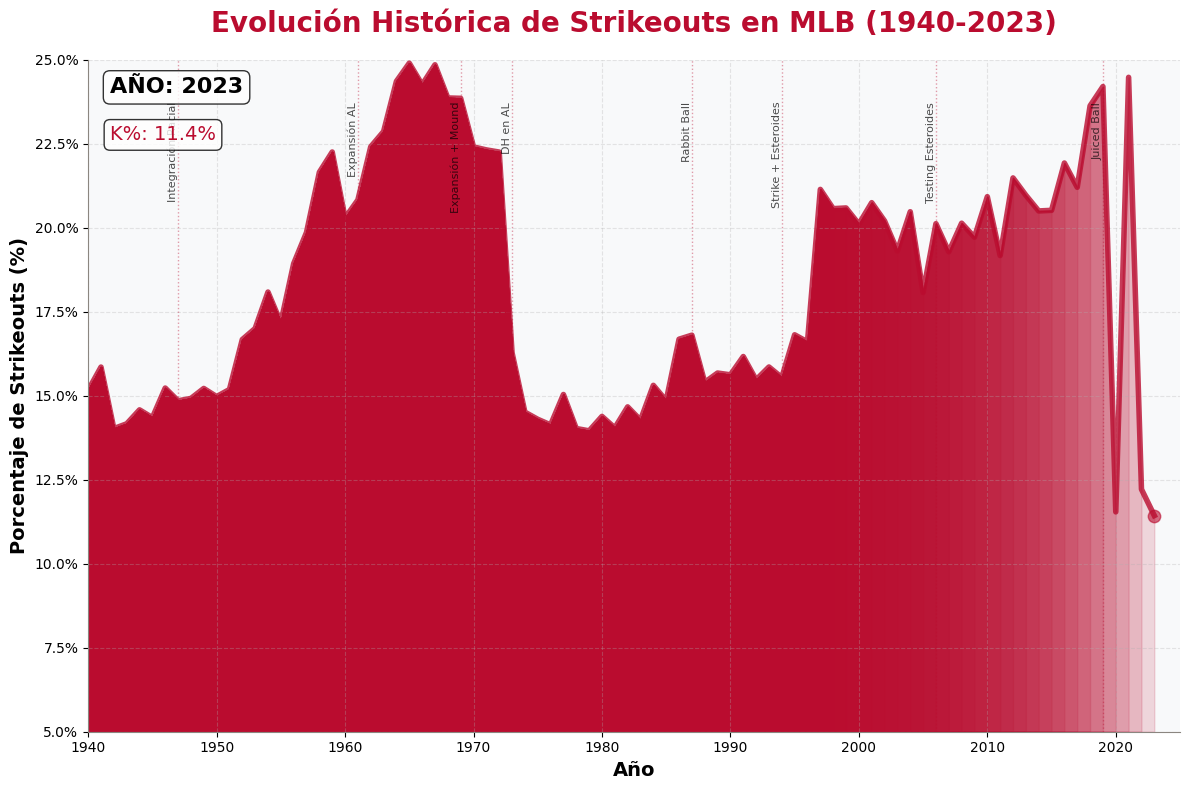


🎬 Creando animación: Declive del Batting Average...
🔍 Rango AVG: 0.238 - 0.271
📊 Años disponibles: 1940-2023
💾 Guardando average_decline.mp4...
⚠️ ffmpeg no disponible, guardando como GIF...
✅ average_decline.gif guardado exitosamente


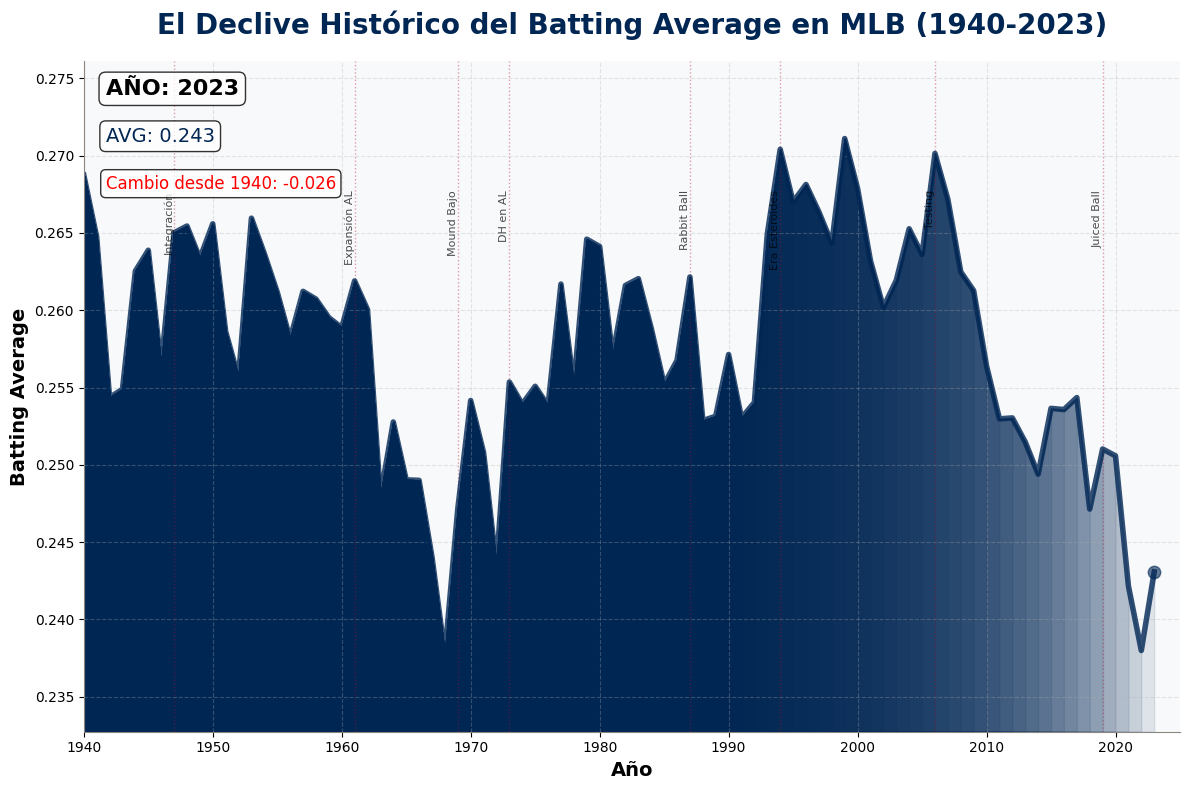


🎬 Creando animación: Evolución del Poder Ofensivo...
💾 Guardando power_evolution.mp4...
⚠️ ffmpeg no disponible, guardando como GIF...
✅ power_evolution.gif guardado exitosamente


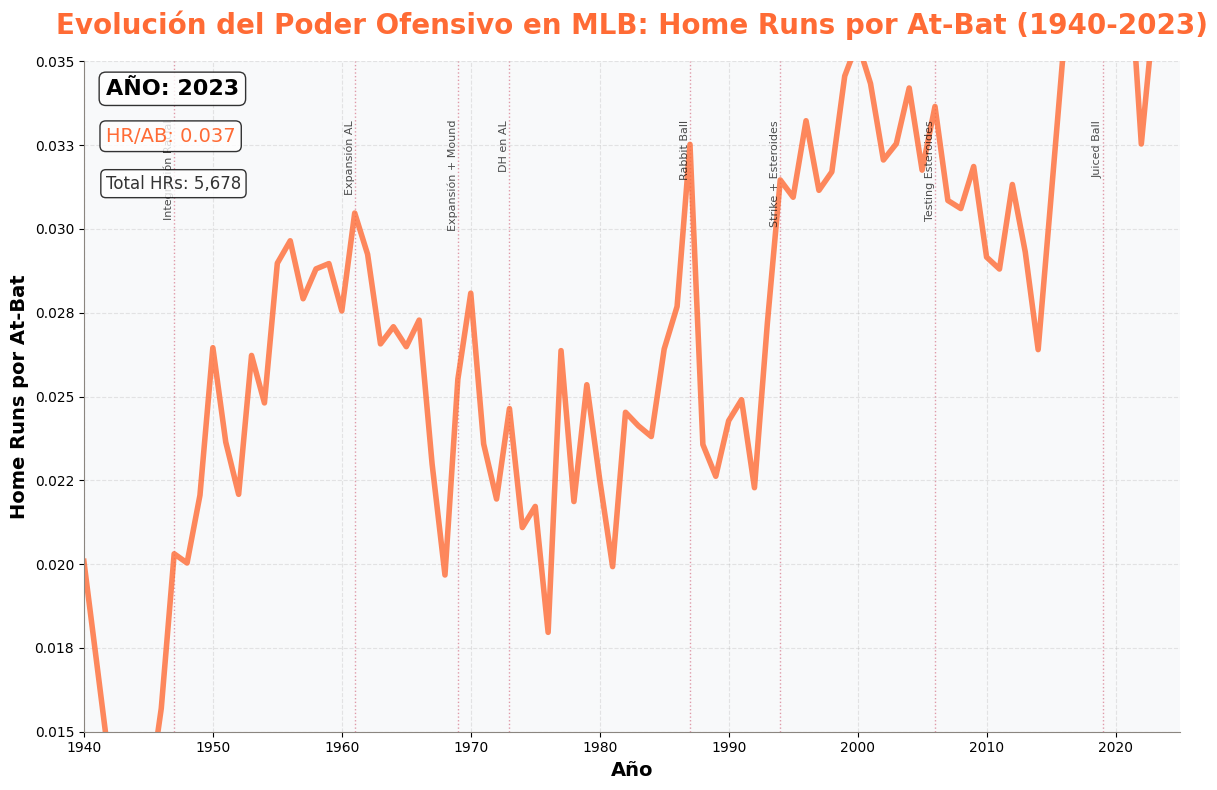


🎉 TODAS LAS ANIMACIONES COMPLETADAS
📁 Archivos generados:
   • strikeout_evolution.mp4/.gif
   • average_decline.mp4/.gif
   • power_evolution.mp4/.gif

💡 Listos para usar en tu presentación!
📝 Nota: Si se generaron GIFs, puedes convertirlos a MP4 online
   Recomendado: https://convertio.co/gif-mp4/

🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬
TFM VISUALIZACIONES DINÁMICAS - COMPLETADO
Sergio Grigorow - Máster Data Science UCM 2024
🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬


In [4]:
# ================================================================
# TFM VISUALIZACIONES DINÁMICAS - EVOLUCIÓN TEMPORAL MLB
# ================================================================
# Autor: Sergio Grigorow
# Máster Data Science UCM - 2024
# 
# Módulo anexo para crear animaciones temporales de métricas clave
# Exporta MP4s de 15 segundos para presentación
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.dates import YearLocator, DateFormatter
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración estética profesional
plt.style.use('default')
sns.set_palette("husl")

# Colores MLB profesionales
MLB_BLUE = '#002654'
MLB_RED = '#BA0C2F'
MLB_GRAY = '#8B8680'

print("🎬 MÓDULO DE VISUALIZACIONES DINÁMICAS - TFM MLB")
print("=" * 60)

# ================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ================================================================

def cargar_datos_temporales():
    """Carga y prepara datos para animaciones temporales"""
    try:
        # Cargar datos principales
        df = pd.read_csv('data/batting_fe.csv')
        print(f"✅ Datos cargados: {len(df):,} registros")
        
        # Filtrar era moderna (1940+) para mejor visualización
        df_modern = df[df['yearID'] >= 1940].copy()
        
        # Calcular HR/AB ratio para poder ofensivo
        df_modern['HR_AB_ratio'] = df_modern['HR'] / df_modern['AB'].replace(0, np.nan)
        
        print(f"📊 Período: {df_modern['yearID'].min()}-{df_modern['yearID'].max()}")
        print(f"🎯 Registros era moderna: {len(df_modern):,}")
        
        return df_modern
        
    except FileNotFoundError:
        print("❌ Error: No se encuentra 'data/batting_fe.csv'")
        print("   Ejecuta primero el notebook principal")
        return None

# ================================================================
# 2. FUNCIONES DE ANIMACIÓN BASE
# ================================================================

def setup_animation_figure(title, ylabel, color_primary=MLB_BLUE):
    """Configura figura base para animaciones"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Estilo profesional
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')
    
    # Configuración de ejes
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(MLB_GRAY)
    ax.spines['bottom'].set_color(MLB_GRAY)
    
    # Títulos y etiquetas
    ax.set_title(title, fontsize=20, fontweight='bold', 
                color=color_primary, pad=20)
    ax.set_xlabel('Año', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    
    return fig, ax

def add_historical_markers(ax, metric_name):
    """Añade marcadores de eventos históricos relevantes"""
    events = {
        1947: "Integración Racial",
        1961: "Expansión AL", 
        1969: "Expansión + Mound",
        1973: "DH en AL",
        1987: "Rabbit Ball",
        1994: "Strike + Esteroides",
        2006: "Testing Esteroides",
        2019: "Juiced Ball"
    }
    
    y_pos = ax.get_ylim()[1] * 0.95
    
    for year, event in events.items():
        if 1940 <= year <= 2023:  # Solo eventos en nuestro rango
            ax.axvline(x=year, color=MLB_RED, alpha=0.4, linestyle=':', linewidth=1)
            ax.text(year, y_pos, event, rotation=90, 
                   fontsize=8, alpha=0.7, ha='right', va='top')

# ================================================================
# 3. ANIMACIÓN 1: EVOLUCIÓN DE K_PCT (1940-2023)
# ================================================================

def create_strikeout_evolution(df):
    """Crea animación de evolución de strikeouts"""
    print("\n🎬 Creando animación: Evolución de Strikeouts...")
    
    # Preparar datos anuales
    yearly_stats = df.groupby('yearID').agg({
        'K_PCT': 'mean',
        'AB': 'sum'
    }).reset_index()
    
    # Configurar figura
    fig, ax = setup_animation_figure(
        'Evolución Histórica de Strikeouts en MLB (1940-2023)',
        'Porcentaje de Strikeouts (%)',
        MLB_RED
    )
    
    # Configurar límites
    ax.set_xlim(1940, 2025)
    ax.set_ylim(0.05, 0.25)
    
    # Formatear eje Y como porcentaje
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
    
    # Añadir marcadores históricos
    add_historical_markers(ax, 'K_PCT')
    
    # Líneas de animación
    line, = ax.plot([], [], linewidth=4, color=MLB_RED, alpha=0.8)
    scatter = ax.scatter([], [], s=80, color=MLB_RED, alpha=0.6, zorder=5)
    
    # Texto dinámico
    year_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, 
                       fontsize=16, fontweight='bold', 
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    value_text = ax.text(0.02, 0.88, '', transform=ax.transAxes, 
                        fontsize=14, color=MLB_RED,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    def animate(frame):
        # Datos hasta el frame actual
        current_year = 1940 + frame
        data_subset = yearly_stats[yearly_stats['yearID'] <= current_year]
        
        if len(data_subset) > 0:
            # Actualizar línea principal
            line.set_data(data_subset['yearID'], data_subset['K_PCT'])
            
            # Área sombreada (efecto visual atractivo)
            if len(data_subset) > 1:
                ax.fill_between(data_subset['yearID'], 0.05, data_subset['K_PCT'], 
                              alpha=0.15, color=MLB_RED)
            
            # Punto actual destacado
            current_data = data_subset.iloc[-1]
            scatter.set_offsets([[current_data['yearID'], current_data['K_PCT']]])
            
            # Textos dinámicos
            year_text.set_text(f'AÑO: {int(current_data["yearID"])}')
            value_text.set_text(f'K%: {current_data["K_PCT"]:.1%}')
        
        return line, scatter, year_text, value_text
    
    # Crear animación (15 segundos = 84 frames total)
    total_years = 2023 - 1940 + 1
    anim = animation.FuncAnimation(fig, animate, frames=total_years, 
                                 interval=180, blit=False, repeat=False)
    
    # Guardar con escritor compatible
    print("💾 Guardando strikeout_evolution.mp4...")
    try:
        # Intentar ffmpeg primero
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=5.6, metadata=dict(artist='TFM-MLB'), bitrate=1800)
            anim.save('strikeout_evolution.mp4', writer=writer)
            print("✅ strikeout_evolution.mp4 guardado exitosamente (ffmpeg)")
        except (KeyError, RuntimeError):
            # Fallback a Pillow como GIF
            print("⚠️ ffmpeg no disponible, guardando como GIF...")
            anim.save('strikeout_evolution.gif', writer='pillow', fps=5.6)
            print("✅ strikeout_evolution.gif guardado exitosamente")
    except Exception as e:
        print(f"❌ Error guardando animación: {e}")
        print("💡 Animación creada pero no guardada")
    
    plt.tight_layout()
    plt.show()
    
    return anim

# ================================================================
# 4. ANIMACIÓN 2: DECLIVE DEL BATTING AVERAGE (1940-2023)
# ================================================================

def create_average_decline(df):
    """Crea animación del declive del batting average"""
    print("\n🎬 Creando animación: Declive del Batting Average...")
    
    # Preparar datos anuales - solo jugadores calificados
    df_qualified = df[df['AB'] >= 100].copy()  # Solo jugadores con suficientes AB
    
    yearly_stats = df_qualified.groupby('yearID').agg({
        'AVG': 'mean',
        'AB': 'sum'
    }).reset_index()
    
    # DIAGNÓSTICO - Imprimir rango de datos
    avg_min = yearly_stats['AVG'].min()
    avg_max = yearly_stats['AVG'].max()
    print(f"🔍 Rango AVG: {avg_min:.3f} - {avg_max:.3f}")
    print(f"📊 Años disponibles: {yearly_stats['yearID'].min()}-{yearly_stats['yearID'].max()}")
    
    # Configurar figura
    fig, ax = setup_animation_figure(
        'El Declive Histórico del Batting Average en MLB (1940-2023)',
        'Batting Average',
        MLB_BLUE
    )
    
    # Configurar límites dinámicos basados en los datos reales
    padding = 0.005  # 5 puntos de padding
    ax.set_xlim(1940, 2025)
    ax.set_ylim(avg_min - padding, avg_max + padding)
    
    # Formatear eje Y con 3 decimales
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))
    
    # Añadir marcadores históricos (ajustados al rango dinámico)
    events_y_pos = avg_max - (avg_max - avg_min) * 0.1  # 10% desde arriba
    
    events = {
        1947: "Integración",
        1961: "Expansión AL", 
        1969: "Mound Bajo",
        1973: "DH en AL",
        1987: "Rabbit Ball",
        1994: "Era Esteroides",
        2006: "Testing",
        2019: "Juiced Ball"
    }
    
    for year, event in events.items():
        if 1940 <= year <= 2023:
            ax.axvline(x=year, color=MLB_RED, alpha=0.4, linestyle=':', linewidth=1)
            ax.text(year, events_y_pos, event, rotation=90, 
                   fontsize=8, alpha=0.7, ha='right', va='top')
    
    # Líneas de animación
    line, = ax.plot([], [], linewidth=4, color=MLB_BLUE, alpha=0.8)
    scatter = ax.scatter([], [], s=80, color=MLB_BLUE, alpha=0.6, zorder=5)
    
    # Área sombreada para mostrar declive
    fill_line, = ax.plot([], [], linewidth=1, color=MLB_BLUE, alpha=0.3)
    
    # Texto dinámico
    year_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, 
                       fontsize=16, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    value_text = ax.text(0.02, 0.88, '', transform=ax.transAxes, 
                        fontsize=14, color=MLB_BLUE,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    # Texto de cambio desde 1940
    change_text = ax.text(0.02, 0.81, '', transform=ax.transAxes, 
                         fontsize=12, color='red',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    def animate(frame):
        current_year = 1940 + frame
        data_subset = yearly_stats[yearly_stats['yearID'] <= current_year]
        
        if len(data_subset) > 0:
            # Actualizar línea principal
            line.set_data(data_subset['yearID'], data_subset['AVG'])
            
            # Punto actual
            current_data = data_subset.iloc[-1]
            scatter.set_offsets([[current_data['yearID'], current_data['AVG']]])
            
            # Área bajo la curva (efecto visual) - ajustada
            if len(data_subset) > 1:
                ax.fill_between(data_subset['yearID'], avg_min - padding, data_subset['AVG'], 
                              alpha=0.1, color=MLB_BLUE)
            
            # Textos dinámicos
            year_text.set_text(f'AÑO: {int(current_data["yearID"])}')
            value_text.set_text(f'AVG: {current_data["AVG"]:.3f}')
            
            # Calcular cambio desde 1940
            if current_year > 1940:
                baseline = yearly_stats[yearly_stats['yearID'] == 1940]['AVG'].iloc[0]
                change = current_data['AVG'] - baseline
                change_text.set_text(f'Cambio desde 1940: {change:+.3f}')
        
        return line, scatter, year_text, value_text, change_text
    
    # Crear animación
    total_years = 2023 - 1940 + 1
    anim = animation.FuncAnimation(fig, animate, frames=total_years, 
                                 interval=180, blit=False, repeat=False)
    
    # Guardar con escritor compatible
    print("💾 Guardando average_decline.mp4...")
    try:
        # Intentar ffmpeg primero
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=5.6, metadata=dict(artist='TFM-MLB'), bitrate=1800)
            anim.save('average_decline.mp4', writer=writer)
            print("✅ average_decline.mp4 guardado exitosamente (ffmpeg)")
        except (KeyError, RuntimeError):
            # Fallback a Pillow como GIF
            print("⚠️ ffmpeg no disponible, guardando como GIF...")
            anim.save('average_decline.gif', writer='pillow', fps=5.6)
            print("✅ average_decline.gif guardado exitosamente")
    except Exception as e:
        print(f"❌ Error guardando animación: {e}")
        print("💡 Animación creada pero no guardada")
    
    plt.tight_layout()
    plt.show()
    
    return anim

# ================================================================
# 5. ANIMACIÓN 3: EVOLUCIÓN DEL PODER OFENSIVO (HR/AB)
# ================================================================

def create_power_evolution(df):
    """Crea animación de evolución del poder ofensivo"""
    print("\n🎬 Creando animación: Evolución del Poder Ofensivo...")
    
    # Preparar datos anuales - solo jugadores con suficientes AB
    df_qualified = df[df['AB'] >= 100].copy()
    
    yearly_stats = df_qualified.groupby('yearID').agg({
        'HR_AB_ratio': 'mean',
        'HR': 'sum',
        'AB': 'sum'
    }).reset_index()
    
    # Recalcular ratio agregado
    yearly_stats['HR_AB_ratio'] = yearly_stats['HR'] / yearly_stats['AB']
    
    # Configurar figura
    fig, ax = setup_animation_figure(
        'Evolución del Poder Ofensivo en MLB: Home Runs por At-Bat (1940-2023)',
        'Home Runs por At-Bat',
        '#FF6B35'  # Naranja dinámico
    )
    
    # Configurar límites
    ax.set_xlim(1940, 2025)
    ax.set_ylim(0.015, 0.035)
    
    # Formatear eje Y como ratio
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))
    
    # Añadir marcadores históricos
    add_historical_markers(ax, 'HR_AB')
    
    # Líneas de animación
    line, = ax.plot([], [], linewidth=4, color='#FF6B35', alpha=0.8)
    scatter = ax.scatter([], [], s=80, color='#FF6B35', alpha=0.6, zorder=5)
    
    # Texto dinámico
    year_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, 
                       fontsize=16, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    value_text = ax.text(0.02, 0.88, '', transform=ax.transAxes, 
                        fontsize=14, color='#FF6B35',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    hr_text = ax.text(0.02, 0.81, '', transform=ax.transAxes, 
                     fontsize=12, color='#333',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    def animate(frame):
        current_year = 1940 + frame
        data_subset = yearly_stats[yearly_stats['yearID'] <= current_year]
        
        if len(data_subset) > 0:
            # Actualizar línea principal
            line.set_data(data_subset['yearID'], data_subset['HR_AB_ratio'])
            
            # Punto actual
            current_data = data_subset.iloc[-1]
            scatter.set_offsets([[current_data['yearID'], current_data['HR_AB_ratio']]])
            
            # Textos dinámicos
            year_text.set_text(f'AÑO: {int(current_data["yearID"])}')
            value_text.set_text(f'HR/AB: {current_data["HR_AB_ratio"]:.3f}')
            hr_text.set_text(f'Total HRs: {int(current_data["HR"]):,}')
        
        return line, scatter, year_text, value_text, hr_text
    
    # Crear animación
    total_years = 2023 - 1940 + 1
    anim = animation.FuncAnimation(fig, animate, frames=total_years, 
                                 interval=180, blit=False, repeat=False)
    
    # Guardar con escritor compatible
    print("💾 Guardando power_evolution.mp4...")
    try:
        # Intentar ffmpeg primero
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=5.6, metadata=dict(artist='TFM-MLB'), bitrate=1800)
            anim.save('power_evolution.mp4', writer=writer)
            print("✅ power_evolution.mp4 guardado exitosamente (ffmpeg)")
        except (KeyError, RuntimeError):
            # Fallback a Pillow como GIF
            print("⚠️ ffmpeg no disponible, guardando como GIF...")
            anim.save('power_evolution.gif', writer='pillow', fps=5.6)
            print("✅ power_evolution.gif guardado exitosamente")
    except Exception as e:
        print(f"❌ Error guardando animación: {e}")
        print("💡 Animación creada pero no guardada")
    
    plt.tight_layout()
    plt.show()
    
    return anim

# ================================================================
# 6. FUNCIÓN PRINCIPAL - EJECUTAR TODAS LAS ANIMACIONES
# ================================================================

def create_all_animations():
    """Función principal para crear todas las animaciones"""
    print("🚀 INICIANDO CREACIÓN DE ANIMACIONES DINÁMICAS")
    print("=" * 60)
    
    # Cargar datos
    df = cargar_datos_temporales()
    if df is None:
        return
    
    # Crear las 3 animaciones
    try:
        print(f"📈 Creando 3 animaciones de 15 segundos cada una...")
        print(f"🎯 Período: 1940-2023 ({2023-1940+1} años)")
        
        # 1. Strikeout Evolution
        anim1 = create_strikeout_evolution(df)
        
        # 2. Average Decline  
        anim2 = create_average_decline(df)
        
        # 3. Power Evolution
        anim3 = create_power_evolution(df)
        
        print("\n" + "=" * 60)
        print("🎉 TODAS LAS ANIMACIONES COMPLETADAS")
        print("📁 Archivos generados:")
        print("   • strikeout_evolution.mp4/.gif")
        print("   • average_decline.mp4/.gif") 
        print("   • power_evolution.mp4/.gif")
        print("\n💡 Listos para usar en tu presentación!")
        print("📝 Nota: Si se generaron GIFs, puedes convertirlos a MP4 online")
        print("   Recomendado: https://convertio.co/gif-mp4/")
        
    except Exception as e:
        print(f"❌ Error en creación de animaciones: {e}")

# ================================================================
# 7. EJECUCIÓN
# ================================================================

if __name__ == "__main__":
    # Ejecutar todas las animaciones
    create_all_animations()
    
    print("\n" + "🎬" * 20)
    print("TFM VISUALIZACIONES DINÁMICAS - COMPLETADO")
    print("Sergio Grigorow - Máster Data Science UCM 2024")
    print("🎬" * 20)